# Exercise 00: Line chart

In [1]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')


## Getting users and log time 

In [2]:
query = pd.io.sql.read_sql(
"""
SELECT uid, datetime
FROM pageviews
WHERE uid LIKE 'user_%'
ORDER BY uid
""",
conn,
)

query

,uid,datetime
0,user_1,2020-04-26 21:53:59.624136
1,user_1,2020-04-26 22:06:19.478143
2,user_1,2020-04-26 22:12:09.614497
3,user_1,2020-04-30 19:29:01.831635
4,user_1,2020-05-05 20:26:32.894852
...,...,...
982,user_30,2020-04-29 16:51:21.877630
983,user_30,2020-05-09 20:30:47.034282
984,user_5,2020-05-22 11:30:18.368990
985,user_9,2020-05-21 16:28:28.217529


## Counting and Grouping 

In [3]:
counter = pd.read_sql("""
SELECT DATE(datetime) AS date, COUNT(*) AS visits
FROM pageviews
GROUP BY DATE(datetime)
ORDER BY DATE(datetime);
""", conn)


## Using plot() func

<Axes: title={'center': 'Views per Day'}, xlabel='date'>

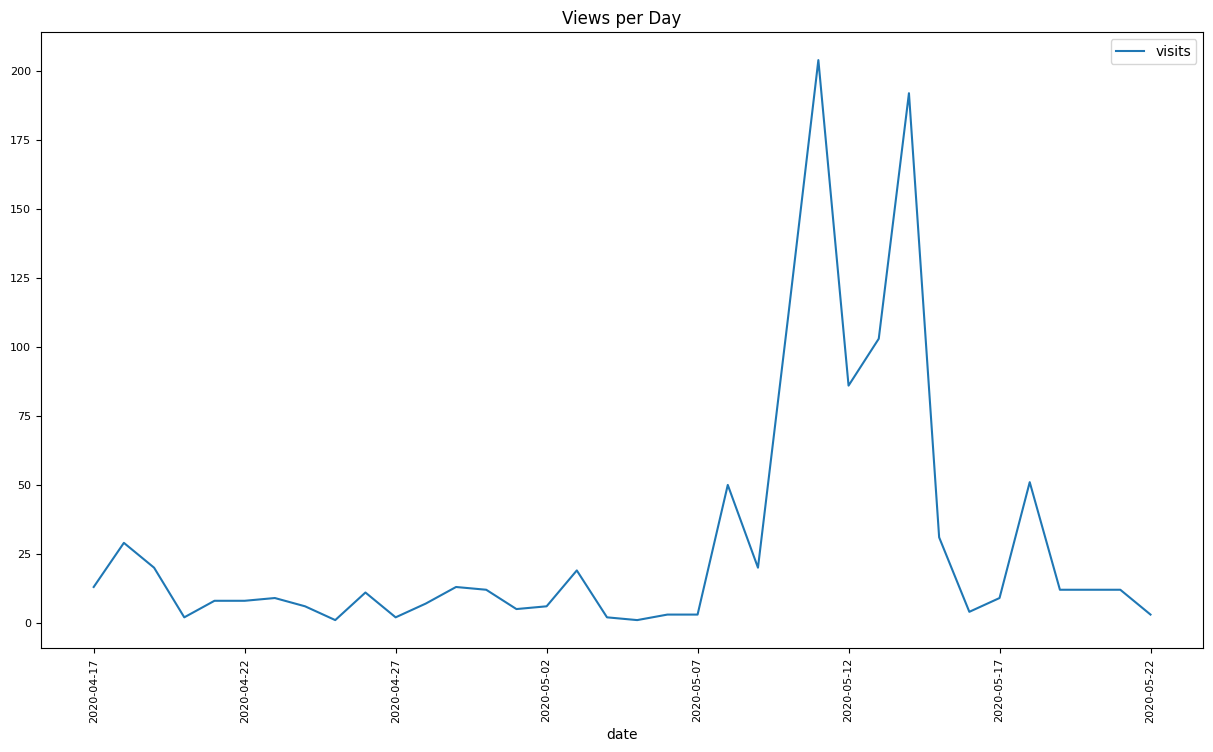

In [4]:
counter = counter.set_index('date')

counter.plot(fontsize=8, figsize=(15,8), title='Views per Day', rot=90)

## Closing connection

In [5]:
conn.close()